Load the graph and FoodOn records to examine protein sources and a separate list of Brazilian foods.

In [1]:
import pandas as pd
from protein_helper import (
    DATA,
    FIGURES,
    STATES_EN,
    STATES_PT,
    compare_preparation,
    select,
    stacked_barh,
    states,
    superclass_path,
)
from rdflib import URIRef

from taco_rdf.cli import load_graph
from taco_rdf.groups import GROUP_LABELS_EN
from taco_rdf.namespaces import ID, OBO, QUERIES_DIR, RDF, RDFS, TACO

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 70)

g = load_graph()
lookup = pd.read_csv(DATA / "foodon_lookup.csv", dtype=str, keep_default_na=False)
first = lookup.iloc[0]
print(f"{len(g):,} triples; FoodOn searches of {first['retrieved']}, release {first['foodon_release']}")
search_queries = lookup[lookup["source"] == "search"].drop_duplicates(
    ["table", "name_pt", "query_en", "status"])
search_counts = search_queries["status"].value_counts().reindex(
    ["found", "no_results", "not_recorded"], fill_value=0)
print(f"Search records: {search_counts['found']} queries with results; "
      f"{search_counts['no_results']} queries with no results; "
      f"{search_counts['not_recorded']} queries without a recorded search.")
print(f"Direct identifier checks: {(lookup['source'] == 'recorded').sum()} records, counted separately from searches.")
if search_counts["not_recorded"]:
    print("Warning: missing search records are unknown outcomes, not evidence of zero results.")
print("Assessments are limited to documented searches and identifier checks, not an exhaustive ontology audit.")
print("A missing exact class does not imply that FoodOn cannot represent a food through facets for ingredients, processes and origin.")
VERDICT_LABELS = {
    "generic class only": "generic class identified in documented checks",
    "taxon only": "taxon identified in documented checks",
}


building from current workbook, corrections and alignments


157,933 triples; FoodOn searches of 2026-09-24, release http://purl.obolibrary.org/obo/foodon/releases/2026-09-20/foodon.owl
Search records: 40 queries with results; 0 queries with no results; 37 queries without a recorded search.
Direct identifier checks: 36 records, counted separately from searches.
Assessments are limited to documented searches and identifier checks, not an exhaustive ontology audit.
A missing exact class does not imply that FoodOn cannot represent a food through facets for ingredients, processes and origin.


Select foods from six groups or with at least 10 g of protein per 100 g as an exploratory population.

In [2]:
PROTEIN_GROUPS = {"Carnes e derivados", "Pescados e frutos do mar", "Leguminosas e derivados",
                  "Leite e derivados", "Ovos e derivados", "Nozes e sementes"}
sources = select(g, "protein_sources")
sources["group_en"] = sources["group"].map(GROUP_LABELS_EN)
sources["criterion"] = sources["group"].map(
    lambda grp: "one of the six groups" if grp in PROTEIN_GROUPS else "10 g of protein or more")
assert (sources.loc[~sources["group"].isin(PROTEIN_GROUPS), "protein"] >= 10).all()
assert sources["food_number"].is_unique
foods = len(set(g.subjects(RDF.type, TACO.Food)))
print(f"{len(sources)} protein sources of {foods} foods: "
      + "; ".join(f"{v} by {k}" for k, v in sources["criterion"].value_counts().items()))
protein = select(g, "food_protein").set_index("food_number")
edge = protein[protein["protein"].between(9.95, 10, inclusive="left")]
edge = edge[~edge.index.isin(sources["food_number"])]
print("left out by the unrounded workbook value although the printed table gives 10.0 g: "
      + "; ".join(f"{n} {r.food_en} ({r.protein:.2f} g)" for n, r in edge.iterrows()))
by_group = sources.groupby("group_en").agg(criterion=("criterion", "first"), foods=("food_number", "size"),
                                           median_protein=("protein", "median"))
by_group.sort_values("foods", ascending=False).round(1)

271 protein sources of 597 foods: 245 by one of the six groups; 26 by 10 g of protein or more


left out by the unrounded workbook value although the printed table gives 10.0 g: 40 Pasta, wheat, raw (10.00 g); 543 Maniçoba (cassava leaf and pork stew) (9.96 g)


,criterion,foods,median_protein
group_en,,,
Meats and derivatives,one of the six groups,123,21.4
Fish and seafood,one of the six groups,50,20.8
Legumes and derivatives,one of the six groups,30,16.6
Milk and dairy products,one of the six groups,24,7.7
Cereals and derivatives,10 g of protein or more,12,11.4
Nuts and seeds,one of the six groups,11,14.0
Prepared foods,10 g of protein or more,10,16.3
Eggs and derivatives,one of the six groups,7,13.7
Miscellaneous,10 g of protein or more,3,14.7


Compare FoodOn types, SKOS mappings and missing links across food groups.

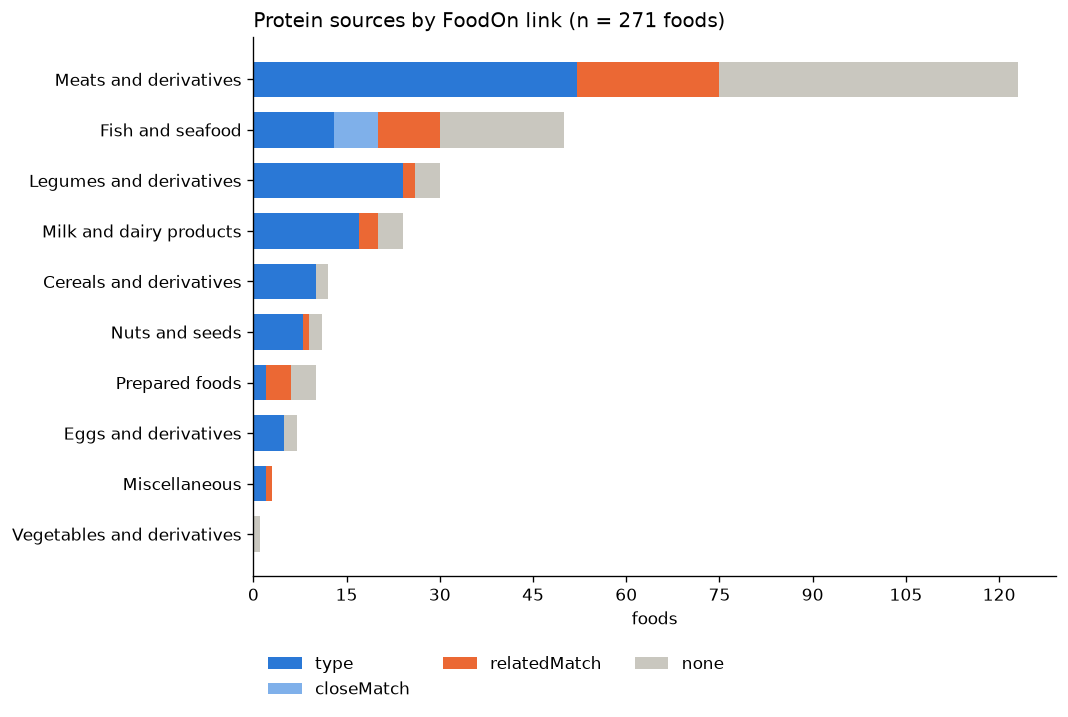

typed with a FoodOn class: 133 of 271 (49%); no FoodOn link: 87 (32%)


,type,closeMatch,relatedMatch,none,share type,share closeMatch,share relatedMatch,share none
group_en,,,,,,,,
Meats and derivatives,52,0,23,48,0.42,0.00,0.19,0.39
Fish and seafood,13,7,10,20,0.26,0.14,0.20,0.40
Legumes and derivatives,24,0,2,4,0.80,0.00,0.07,0.13
Milk and dairy products,17,0,3,4,0.71,0.00,0.12,0.17
Cereals and derivatives,10,0,0,2,0.83,0.00,0.00,0.17
Nuts and seeds,8,0,1,2,0.73,0.00,0.09,0.18
Prepared foods,2,0,4,4,0.20,0.00,0.40,0.40
Eggs and derivatives,5,0,0,2,0.71,0.00,0.00,0.29
Miscellaneous,2,0,1,0,0.67,0.00,0.33,0.00


In [3]:
RELATIONS = {"type": "#2a78d6", "closeMatch": "#7fb0ea", "relatedMatch": "#eb6834", "none": "#c9c7bf"}
coverage = pd.crosstab(sources["group_en"], sources["relation"])
coverage = coverage.reindex(columns=list(RELATIONS), fill_value=0)
coverage = coverage.loc[coverage.sum(axis=1).sort_values(ascending=False).index]
stacked_barh(coverage, RELATIONS, f"Protein sources by FoodOn link (n = {len(sources)} foods)",
             FIGURES / "foodon_link_by_group.svg")

share = coverage.div(coverage.sum(axis=1), axis=0).round(2)
share.columns = [f"share {c}" for c in share.columns]
total = sources["relation"].value_counts()
print(f"typed with a FoodOn class: {total['type']} of {len(sources)} ({total['type'] / len(sources):.0%}); "
      f"no FoodOn link: {total['none']} ({total['none'] / len(sources):.0%})")
coverage.join(share)

Inspect food properties for explicit representations of preparation and origin.

In [4]:
properties = select(g, "food_properties")
properties["property"] = properties["property"].str.replace(r".*[#/]", "", regex=True)
properties

,property,foods
0,type,597
1,label,597
2,prefLabel,597
3,foodNumber,597
4,inGroup,597
5,alignment,436
6,relatedMatch,114
7,closeMatch,11
8,footnoteMarker,2


Compare preparation words lexically without evaluating recipes, durations, temperatures or class definitions.

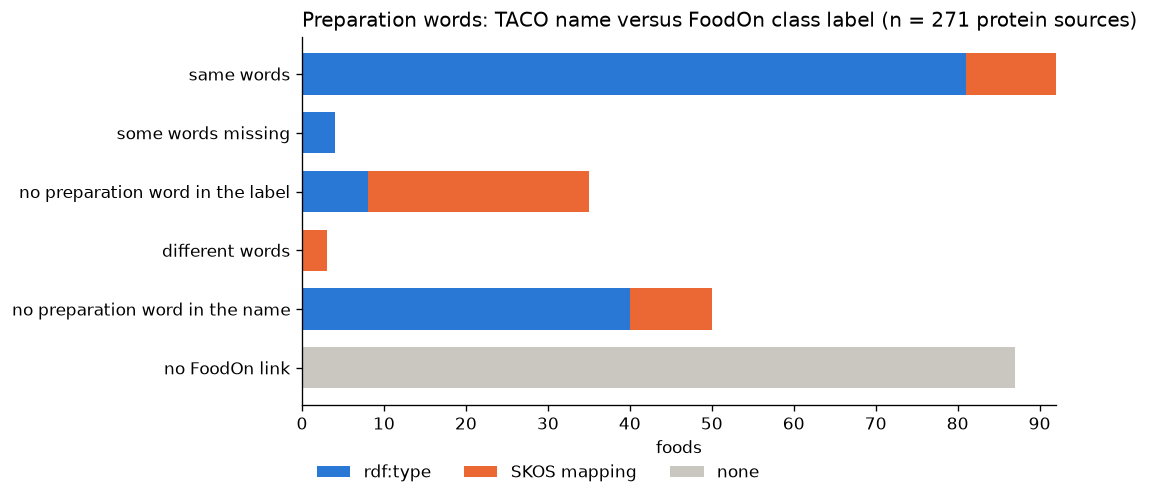

link,SKOS mapping,none,rdf:type
preparation,,,
same words,11,0,81
some words missing,0,0,4
no preparation word in the label,27,0,8
different words,3,0,0
no preparation word in the name,10,0,40
no FoodOn link,0,87,0


In [5]:
sources["taco_states"] = sources["food"].map(lambda name: states(name, STATES_PT))
sources["foodon_states"] = sources["foodon_label"].map(lambda label: states(label, STATES_EN))
sources["preparation"] = [
    compare_preparation(t, f, r != "none")
    for t, f, r in zip(sources["taco_states"], sources["foodon_states"], sources["relation"], strict=True)
]
sources["link"] = sources["relation"].map(
    lambda r: "rdf:type" if r == "type" else ("none" if r == "none" else "SKOS mapping"))

LINKS = {"rdf:type": "#2a78d6", "SKOS mapping": "#eb6834", "none": "#c9c7bf"}
outcome = pd.crosstab(sources["preparation"], sources["link"])
order = ["same words", "some words missing", "label says only cooked", "no preparation word in the label",
         "different words", "no preparation word in the name", "no FoodOn link"]
outcome = outcome.reindex([o for o in order if o in outcome.index])
stacked_barh(outcome, LINKS, f"Preparation words: TACO name versus FoodOn class label "
                             f"(n = {len(sources)} protein sources)",
             FIGURES / "preparation_words.svg")
outcome

Compare FoodOn typing rates across preparation states.

In [6]:
HEAT = {"cooked", "grilled", "roasted", "fried", "sauteed", "steamed", "precooked"}

def heat(taco_states):
    if taco_states & HEAT:
        return "heat-treated"
    return "raw" if "raw" in taco_states else "other"

named = sources[sources["taco_states"].map(bool)].assign(state=lambda d: d["taco_states"].map(heat))
by_state = pd.crosstab(named["state"], named["link"]).reindex(columns=list(LINKS), fill_value=0)
by_state["share typed"] = (by_state["rdf:type"] / by_state.sum(axis=1)).round(2)
by_state

link,rdf:type,SKOS mapping,none,share typed
state,,,,
heat-treated,25,31,51,0.23
other,2,0,5,0.29
raw,66,10,19,0.69


List typed foods with preparation words missing from class labels as candidates for review.

In [7]:
strong = sources[(sources["link"] == "rdf:type")
                 & sources["preparation"].isin(["no preparation word in the label", "some words missing",
                                              "different words"])]
strong[["food_number", "food", "food_en", "foodon_label", "preparation"]]

,food_number,food,food_en,foodon_label,preparation
0,7,"Aveia, flocos, crua","Oats, rolled, raw",rolled oats,no preparation word in the label
5,41,"Macarrão, trigo, cru, com ovos","Pasta, wheat, raw, with eggs",01790 - fresh egg pasta (efsa foodex2),no preparation word in the label
126,386,"Coxinha de frango, frita","Coxinha (chicken croquette), fried",chicken croquette,no preparation word in the label
129,389,"Empada de frango, pré-cozida, assada","Empada (chicken pie), precooked, baked",chicken pie,no preparation word in the label
130,390,"Empada, de frango, pré-cozida","Empada (chicken pie), precooked",chicken pie,no preparation word in the label
156,416,"Hambúrguer, bovino, frito","Hamburger patty, beef, fried",beef hamburger (dish),no preparation word in the label
165,425,"Peru, congelado, assado","Turkey, frozen, roasted",turkey roast,no preparation word in the label
166,426,"Peru, congelado, cru","Turkey, frozen, raw",turkey meat (raw),some words missing
172,432,"Porco, lombo, assado","Pork, loin, roasted",pork loin center roast,no preparation word in the label
177,437,"Porco, rabo, salgado, cru","Pork, tail, salted, raw",pork tail (raw),some words missing


Inspect searches for FoodOn classes matching the preparations described by TACO.

In [8]:
probes = pd.read_csv(DATA / "preparation_probes.csv", dtype=str, keep_default_na=False)
probes["search_assessment"] = probes["verdict"].replace(VERDICT_LABELS)
probes[["name_pt", "name_en", "food_numbers", "query_en", "search_assessment", "foodon_label", "taco_link"]]

,name_pt,name_en,food_numbers,query_en,search_assessment,foodon_label,taco_link
0,"Contra-filé, grelhado","Striploin, grilled",344 346,beef strip loin (broiled),not found in documented searches,,relatedMatch beef loin
1,"Filé mignon, grelhado","Tenderloin, grilled",358,beef tenderloin (broiled),not found in documented searches,,relatedMatch beef loin
2,"Miolo de alcatra, grelhado","Top sirloin, grilled",370,beef top sirloin (broiled),search not recorded,,none
3,"Língua, cozida","Beef tongue, cooked",365,beef tongue (cooked),not found in documented searches,,none
4,"Fígado, grelhado","Beef liver, grilled",356,beef liver (cooked),not found in documented searches,,relatedMatch beef liver
5,"Bucho, cozido","Beef tripe, cooked",332,beef tripe (cooked),search not recorded,,none
6,"Frango, peito, sem pele, grelhado","Chicken breast, skinless, grilled",410,chicken breast (grilled),search not recorded,,none
7,"Frango, peito, com pele, assado","Chicken breast, with skin, roasted",406,chicken breast (roasted),not found in documented searches,,none
8,"Frango, sobrecoxa, assada","Chicken thigh, roasted",411 413,chicken thigh (roasted),search not recorded,,none
9,"Frango, coxa, com pele, assada","Chicken drumstick, with skin, roasted",396,chicken drumstick (roasted),search not recorded,,none


Compare nutrient ranges among distinct food records sharing a FoodOn class.

In [9]:
shared = select(g, "foods_per_foodon_type")
shared = shared.merge(sources[["food_number", "food_en"]], on="food_number")
merged = shared.groupby(["foodon_class", "foodon_label"]).agg(
    foods=("food", "size"), names=("food", "; ".join), names_en=("food_en", "; ".join),
    protein_min=("protein", "min"), protein_max=("protein", "max"),
    lipids_min=("lipids", "min"), lipids_max=("lipids", "max"),
    sodium_min=("sodium", "min"), sodium_max=("sodium", "max"))
merged = merged[merged["foods"] > 1]
print(f"{len(merged)} FoodOn classes are shared by 2 or more distinct food records ({merged['foods'].sum()} foods).")
print("The food identifiers and their nutrient measurements remain separate.")
merged.sort_values("foods", ascending=False).round(1)

6 FoodOn classes are shared by 2 or more distinct food records (13 foods).
The food identifiers and their nutrient measurements remain separate.


,,foods,names,names_en,protein_min,protein_max,lipids_min,lipids_max,sodium_min,sodium_max
foodon_class,foodon_label,,,,,,,,,
FOODON_03307997,weakfish (raw),3,"Pescada, branca, crua; Pescada, filé, cru; Pescadinha, crua","Weakfish, white (pescada branca), raw; Weakfish (pescada), fillet,...",15.5,16.6,1.1,4.6,76.2,120.3
FOODON_00004375,pinto bean (cooked),2,"Feijão, carioca, cozido; Feijão, rajado, cozido","Bean, carioca, cooked; Bean, rajado (speckled), cooked",4.8,5.5,0.4,0.5,0.7,1.8
FOODON_02000070,beef shoulder clod (raw),2,"Carne, bovina, paleta, com gordura, crua; Carne, bovina, paleta, s...","Beef, shoulder clod (paleta), with fat, raw; Beef, shoulder clod (...",21.0,21.4,5.7,7.5,64.9,65.9
FOODON_02000124,"beef strip loin (boneless, raw)",2,"Carne, bovina, contra-filé, com gordura, cru; Carne, bovina, contr...","Beef, striploin (contra-filé), with fat, raw; Beef, striploin (con...",21.2,24.0,6.0,12.8,44.1,52.9
FOODON_03000089,pinto bean (raw),2,"Feijão, carioca, cru; Feijão, rajado, cru","Bean, carioca, raw; Bean, rajado (speckled), raw",17.3,20.0,1.2,1.3,13.7,13.7
FOODON_03307577,chicken pie,2,"Empada de frango, pré-cozida, assada; Empada, de frango, pré-cozida","Empada (chicken pie), precooked, baked; Empada (chicken pie), prec...",6.9,7.3,15.6,22.9,524.9,770.7


Inspect poultry placement under mammalian meat in the hierarchy separately from mapping correctness.

In [10]:
MAMMALIAN_MEAT = URIRef(OBO + "FOODON_00001006")
under = select(g, "foods_in_foodon_class", folder=QUERIES_DIR, **{"class": f"<{MAMMALIAN_MEAT}>"})
under = under.drop_duplicates("food_number")
poultry = under[under["food"].str.contains(r"^(?:frango|galinha|peru|pato)\b", case=False, regex=True)]
for n, name in zip(poultry["food_number"], poultry["food_en"], strict=True):
    food_type = next(t for t in g.objects(ID[f"food/{n}"], RDF.type) if str(t).startswith(str(OBO)))
    path = superclass_path(g, food_type, MAMMALIAN_MEAT)
    assert path is not None, n
    print(f"{n} {name}: " + " > ".join(str(g.value(c, RDFS.label)) for c in path))
print(f"{len(poultry)} of the {len(under)} foods under mammalian meat food product are poultry")
under[["food_number", "food", "food_en", "foodon_type"]]

398 Chicken, drumstick, skinless, cooked: chicken drumstick (cooked) > meat (cooked) > meat (prepared) > meat (whole or pieces) > mammalian meat food product
408 Chicken, breast, skinless, cooked: chicken breast (cooked) > meat (cooked) > meat (prepared) > meat (whole or pieces) > mammalian meat food product
2 of the 14 foods under mammalian meat food product are poultry


,food_number,food,food_en,foodon_type
0,326,"Carne, bovina, acém, moído, cozido","Beef, chuck (acém), ground, cooked",ground beef (cooked)
1,327,"Carne, bovina, acém, moído, cru","Beef, chuck (acém), ground, raw","beef (ground, raw)"
2,329,"Carne, bovina, acém, sem gordura, cru","Beef, chuck (acém), fat trimmed, raw",beef chuck (raw)
3,330,"Carne, bovina, almôndegas, cruas","Beef, meatballs, raw",meatball (raw)
4,333,"Carne, bovina, bucho, cru","Beef, tripe (bucho), raw",beef tripe (raw)
5,387,"Croquete, de carne, cru","Croquette, beef, raw",meat croquette (raw)
6,398,"Frango, coxa, sem pele, cozida","Chicken, drumstick, skinless, cooked",chicken drumstick (cooked)
7,408,"Frango, peito, sem pele, cozido","Chicken, breast, skinless, cooked",chicken breast (cooked)
8,415,"Hambúrguer, bovino, cru","Hamburger patty, beef, raw",ground beef patty (raw)
9,421,"Lingüiça, porco, crua","Sausage (linguiça), pork, raw",pork sausage (raw)


Compare sodium in salted or dried foods with selected fresh cuts and inspect their preparation labels.

In [11]:
sodium = select(g, "nutrient_values", key="sodium").set_index("food_number")["value"]
treated = sources[sources["taco_states"].map(lambda s: bool(s & {"salted", "dried"}))].copy()
treated["sodium_mg"] = treated["food_number"].map(sodium).round(0)

NOT_FRESH = {
    279: "salted cod", 330: "meatballs", 339: "charque, salted and sun-dried",
    385: "carne seca, salted and dried", 387: "croquette", 415: "hamburger patty",
    418: "chicken sausage", 421: "pork sausage", 434: "salted pork ear", 437: "salted pork tail",
    441: "kibbeh, a dish", 444: "fatback, sold fresh or salted",
}
meat_fish = sources[sources["group"].isin(["Carnes e derivados", "Pescados e frutos do mar"])]
raw = meat_fish[meat_fish["taco_states"].map(lambda s: "raw" in s)]
assert set(NOT_FRESH) <= set(raw["food_number"])
fresh = raw[~raw["food_number"].isin(NOT_FRESH)].copy()
fresh["sodium_mg"] = fresh["food_number"].map(sodium).round(0)
median = fresh["sodium_mg"].median()
high = fresh[fresh["sodium_mg"] > 3 * median]
print(f"reference: {len(fresh)} raw fresh cuts of meat, poultry, fish and seafood; "
      f"median sodium {median:.0f} mg per 100 g")
print("left out because the product itself implies added salt or other ingredients: "
      + "; ".join(f"{n} {why}" for n, why in NOT_FRESH.items()))
print("kept, above three times the median, although the name does not say seasoned: "
      + "; ".join(f"{r.food_number} {r.food_en} ({r.sodium_mg:.0f} mg)" for r in high.itertuples()))
treated[["food_number", "food", "food_en", "relation", "foodon_label", "preparation", "sodium_mg"]]

reference: 61 raw fresh cuts of meat, poultry, fish and seafood; median sodium 62 mg per 100 g
left out because the product itself implies added salt or other ingredients: 279 salted cod; 330 meatballs; 339 charque, salted and sun-dried; 385 carne seca, salted and dried; 387 croquette; 415 hamburger patty; 418 chicken sausage; 421 pork sausage; 434 salted pork ear; 437 salted pork tail; 441 kibbeh, a dish; 444 fatback, sold fresh or salted
kept, above three times the median, although the name does not say seasoned: 285 Shrimp, Rio Grande, large, raw (201 mg); 426 Turkey, frozen, raw (711 mg)


,food_number,food,food_en,relation,foodon_label,preparation,sodium_mg
12,114,"Coentro, folhas desidratadas","Coriander, leaves, dehydrated",none,NaN,no FoodOn link,18.0
19,279,"Bacalhau, salgado, cru","Cod, salted (bacalhau), raw",none,NaN,no FoodOn link,13585.0
20,280,"Bacalhau, salgado, refogado","Cod, salted (bacalhau), sauteed",relatedMatch,cod,no preparation word in the label,1256.0
78,338,"Carne, bovina, charque, cozido","Beef, charque (salted sun-dried beef), cooked",none,NaN,no FoodOn link,1443.0
79,339,"Carne, bovina, charque, cru","Beef, charque (salted sun-dried beef), raw",none,NaN,no FoodOn link,5875.0
124,384,"Carne, bovina, seca, cozida","Beef, carne seca (salted dried beef), cooked",none,NaN,no FoodOn link,1943.0
125,385,"Carne, bovina, seca, crua","Beef, carne seca (salted dried beef), raw",none,NaN,no FoodOn link,4440.0
174,434,"Porco, orelha, salgada, crua","Pork, ear, salted, raw",relatedMatch,pork ear,no preparation word in the label,616.0
177,437,"Porco, rabo, salgado, cru","Pork, tail, salted, raw",type,pork tail (raw),some words missing,1158.0
231,558,"Amendoim, torrado, salgado","Peanut, roasted, salted",type,"peanut (skin off, salted, roasted)",same words,376.0


Display the fresh cuts used as the sodium reference.

In [12]:
fresh[["food_number", "food", "food_en", "sodium_mg"]]

,food_number,food,food_en,sodium_mg
15,275,"Abadejo, filé, congelado, cru","Pollock (abadejo), fillet, frozen, raw",79.0
18,278,"Atum, fresco, cru","Tuna, fresh, raw",30.0
23,283,"Cação, posta, crua","Shark (cação), steak, raw",176.0
25,285,"Camarão, Rio Grande, grande, cru","Shrimp, Rio Grande, large, raw",201.0
28,288,"Corimba, cru","Corimba (Prochilodus), raw",47.0
31,291,"Corvina de água doce, crua","Croaker, freshwater, raw",45.0
32,292,"Corvina do mar, crua","Croaker, sea, raw",68.0
36,296,"Lambari, congelado, cru","Lambari (Astyanax), frozen, raw",48.0
38,298,"Lambari, fresco, cru","Lambari (Astyanax), fresh, raw",41.0
42,302,"Merluza, filé, cru","Hake, fillet, raw",80.0


Inspect protein and amino acid mappings to ChEBI and CDNO.

In [13]:
nutrients = select(g, "protein_nutrients")
nutrients["mapping"] = nutrients["relation"] + ": " + nutrients["target_label"].fillna("")
nutrients.pivot_table(index="key", columns="ontology", values="mapping", aggfunc="first").fillna("none")

ontology,CDNO,CHEBI
key,,
alanine,closeMatch: concentration of alanine in material entity,closeMatch: L-alanine
arginine,closeMatch: concentration of arginine in material entity,closeMatch: L-arginine
aspartic_acid,closeMatch: concentration of aspartic acid in material entity,closeMatch: L-aspartic acid
cystine,relatedMatch: concentration of cysteine in material entity,closeMatch: L-cystine
glutamic_acid,closeMatch: concentration of glutamic acid in material entity,closeMatch: L-glutamic acid
glycine,closeMatch: concentration of glycine in material entity,closeMatch: glycine
histidine,closeMatch: concentration of histidine in material entity,closeMatch: L-histidine
isoleucine,closeMatch: concentration of isoleucine in material entity,closeMatch: L-isoleucine
leucine,closeMatch: concentration of leucine in material entity,closeMatch: L-leucine


Count numeric, trace, inapplicable, provisional and absent protein and amino acid values.

In [14]:
status = select(g, "protein_value_status")
status = status[status["food_number"].isin(sources["food_number"])]
counts = pd.crosstab(status["key"], status["status"])
counts["absent"] = len(sources) - counts.sum(axis=1)
with_amino_acids = status.loc[status["key"] != "protein", "food_number"].nunique()
print(f"amino acids are given for {with_amino_acids} of {len(sources)} protein sources")
counts

amino acids are given for 10 of 271 protein sources


status,Measured,UnderReevaluation,absent
key,,,
alanine,10,0,261
arginine,10,0,261
aspartic_acid,10,0,261
cystine,10,0,261
glutamic_acid,10,0,261
glycine,10,0,261
histidine,10,0,261
isoleucine,10,0,261
leucine,10,0,261


Load the separate curated list of Brazilian foods and compare its TACO entries with the exploratory protein population.

In [15]:
regional = pd.read_csv(DATA / "regional_protein_foods.csv", dtype=str, keep_default_na=False)
in_taco = regional["in_taco"] == "yes"
assert (regional["food_numbers"] != "").eq(in_taco).all()
numbers = regional.assign(food_number=regional["food_numbers"].str.split()).explode("food_number")
numbers = numbers.dropna(subset=["food_number"]).astype({"food_number": int})
numbers["food_en"] = numbers["food_number"].map(protein["food_en"])
numbers["protein"] = numbers["food_number"].map(protein["protein"])
numbers["in_population_1"] = numbers["food_number"].isin(sources["food_number"])
outside = numbers[~numbers["in_population_1"]]
print(f"{len(regional)} items, {in_taco.sum()} in TACO with {len(numbers)} TACO foods; "
      f"{numbers['in_population_1'].sum()} of these foods are in population 1, {len(outside)} are not")
outside[["particularity", "name_pt", "food_number", "food_en", "protein"]].round(2)

52 items, 43 in TACO with 69 TACO foods; 59 of these foods are in population 1, 10 are not


,particularity,name_pt,food_number,food_en,protein
34,Brazilian dish,Feijoada,540,Feijoada (black bean and pork stew),8.67
36,Brazilian dish,Acarajé,525,Acarajé (black-eyed pea fritter),8.35
37,Brazilian dish,Vatapá,554,"Vatapá (dried shrimp, nuts, coconut milk and palm oil)",6.00
38,Brazilian dish,Camarão à baiana,531,Camarão à baiana (Bahian shrimp stew),7.94
39,Brazilian dish,Baião de dois,527,"Baião de dois (rice, cowpeas, fatback and coalho cheese)",6.24
41,Brazilian dish,Quibebe,544,Quibebe (squash with carne seca),8.56
42,Brazilian dish,Cuxá,535,Cuxá sauce (roselle leaf sauce),5.64
43,Brazilian dish,Maniçoba,543,Maniçoba (cassava leaf and pork stew),9.96
44,Brazilian dish,Tacacá,550,Tacacá (tucupi soup with shrimp and jambu),6.96
47,Brazilian dish,Vaca atolada,553,Vaca atolada (beef ribs with cassava),5.12


Summarize recorded FoodOn search assessments for the curated Brazilian food list.

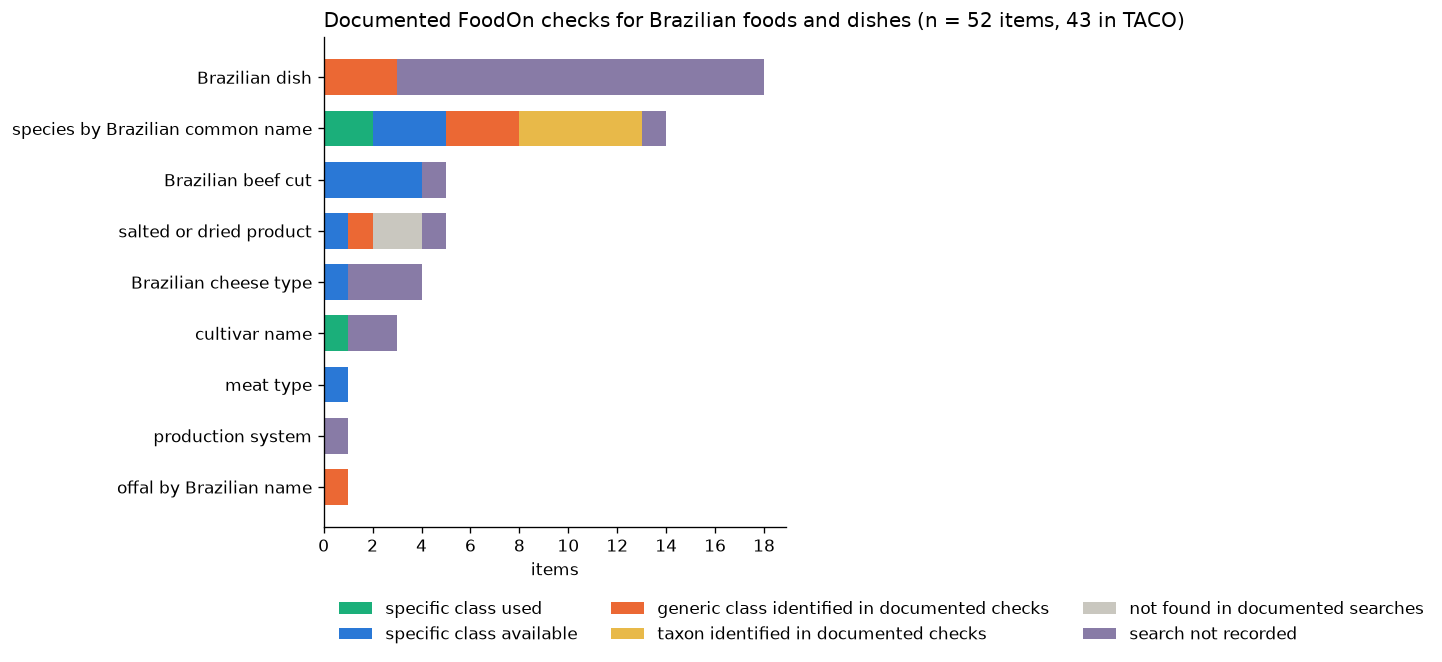

search_assessment,specific class used,specific class available,generic class identified in documented checks,taxon identified in documented checks,not found in documented searches,search not recorded
particularity,,,,,,
Brazilian dish,0,0,3,0,0,15
species by Brazilian common name,2,3,3,5,0,1
Brazilian beef cut,0,4,0,0,0,1
salted or dried product,0,1,1,0,2,1
Brazilian cheese type,0,1,0,0,0,3
cultivar name,1,0,0,0,0,2
meat type,0,1,0,0,0,0
production system,0,0,0,0,0,1
offal by Brazilian name,0,0,1,0,0,0


In [16]:
VERDICTS = {"specific class used": "#1baf7a", "specific class available": "#2a78d6",
            "generic class identified in documented checks": "#eb6834",
            "taxon identified in documented checks": "#e8b949",
            "not found in documented searches": "#c9c7bf",
            "search not recorded": "#887ba6"}
regional["search_assessment"] = regional["verdict"].replace(VERDICT_LABELS)
verdicts = pd.crosstab(regional["particularity"], regional["search_assessment"])
verdicts = verdicts.loc[verdicts.sum(axis=1).sort_values(ascending=False).index]
stacked_barh(verdicts, VERDICTS, f"Documented FoodOn checks for Brazilian foods and dishes "
                                 f"(n = {len(regional)} items, {in_taco.sum()} in TACO)",
             FIGURES / "regional_verdicts.svg", xlabel="items")
verdicts.reindex(columns=[v for v in VERDICTS if v in verdicts.columns], fill_value=0)

Display the curated list with documented recipes because dish names alone do not establish ingredients.

In [17]:
searches = lookup[(lookup["table"] == "regional") & (lookup["source"] == "search")]
first_hit = searches[searches["rank"] == "1"].set_index("name_pt")["label"]
regional["first_search_result"] = regional["name_pt"].map(first_hit).fillna("")
dishes = regional[(regional["particularity"] == "Brazilian dish") & in_taco]
assert (dishes["taco_page"] != "").all() and (dishes["taco_recipe"] != "").all()
columns = ["particularity", "name_pt", "name_en", "food_numbers", "search_assessment", "foodon_label",
           "first_search_result", "taco_page", "taco_recipe", "note"]
regional[columns]

,particularity,name_pt,name_en,food_numbers,search_assessment,foodon_label,first_search_result,taco_page,taco_recipe,note
0,Brazilian beef cut,Picanha,Top sirloin cap (picanha),380 381 382 383,specific class available,beef culotte steak,beef culotte roast,,,cut without preparation; no grilled form identified in this analysis
1,Brazilian beef cut,Cupim,Zebu hump (cupim),353 354,search not recorded,,,,,hump of zebu cattle (Bos indicus)
2,Brazilian beef cut,Fraldinha,Flap (fraldinha),361 362,specific class available,beef sirloin bavette flap,beef chuck flap/edge roast (raw),,,cut without preparation; no cooked form identified in this analysis
3,Brazilian beef cut,Patinho,Knuckle (patinho),376 377,specific class available,beef sirloin tip,beef sirloin tip,,,cut without preparation; no grilled form identified in this analysis
4,Brazilian beef cut,Capa de contra-filé,Ribeye cap (capa de contra-filé),334 335 336 337,specific class available,beef ribeye cap steak (raw),beef ribeye cap steak (raw),,,used as skos:relatedMatch for the raw cut; no grilled form identif...
5,offal by Brazilian name,Dobradinha,"Dobradinha (beef tripe, boiled)",536,generic class identified in documented checks,tripe,,124,"beef tripe boiled in water, nothing added","TACO's item is tripe boiled in water, not a stew"
6,salted or dried product,Charque,Salted sun-dried beef (charque),338 339,not found in documented searches,,beef jerky,,,"a candidate considered is beef jerky (FOODON_03302103), a differen..."
7,salted or dried product,Carne seca (jabá),Salted dried beef (carne seca),384 385,not found in documented searches,,mum,,,
8,salted or dried product,Carne de sol,"Lightly salted, air-dried beef (carne de sol)",,search not recorded,,,,,not in TACO 4th edition
9,salted or dried product,Bacalhau salgado,Salted cod (bacalhau),279 280,specific class available,codfish (salted),26180 - salted cod (efsa foodex2),,,279 unaligned; 280 related to generic cod


Summarize the results for both populations.

In [18]:
print(f"population 1, protein sources (an operational cut): {len(sources)} foods")
print(f"  typed with FoodOn: {total['type']}; with no FoodOn link: {total['none']}")
print(f"  typed foods whose class label misses a preparation word of the name (to review): {len(strong)}")
print(f"  FoodOn classes shared by 2 or more distinct food records: {len(merged)}")
print(f"  poultry foods FoodOn places under mammalian meat food product (hierarchy to review): {len(poultry)}")
print(f"population 2, Brazilian foods and dishes: {len(regional)} items, {in_taco.sum()} in TACO")
print(f"  {len(outside)} of their {len(numbers)} TACO foods are outside population 1: "
      + ", ".join(outside["name_pt"]))
print("  items in TACO by documented assessment:", regional[in_taco]["search_assessment"].value_counts().to_dict())
print("  items not in TACO:", ", ".join(regional.loc[~in_taco, "name_pt"]))

population 1, protein sources (an operational cut): 271 foods
  typed with FoodOn: 133; with no FoodOn link: 87
  typed foods whose class label misses a preparation word of the name (to review): 12
  FoodOn classes shared by 2 or more distinct food records: 6
  poultry foods FoodOn places under mammalian meat food product (hierarchy to review): 2
population 2, Brazilian foods and dishes: 52 items, 43 in TACO
  10 of their 69 TACO foods are outside population 1: Feijoada, Acarajé, Vatapá, Camarão à baiana, Baião de dois, Quibebe, Cuxá, Maniçoba, Tacacá, Vaca atolada
  items in TACO by documented assessment: {'search not recorded': 19, 'specific class available': 7, 'generic class identified in documented checks': 7, 'taxon identified in documented checks': 5, 'specific class used': 3, 'not found in documented searches': 2}
  items not in TACO: Carne de sol, Pirarucu, Tambaqui, Sururu, Carne de bode e de carneiro, Queijo coalho, Buchada, Panelada, Moqueca
